# Trabajo Práctico 2 - Aprendizaje Supervisado y Validación Cruzada
## Predicción de Precios de Vivienda mediante Modelos de Regresión
### Por: Samuel Angel Cardona

Este proyecto diseña, implementa y evalúa un flujo completo de aprendizaje automático supervisado para predecir el precio de inmuebles residenciales a partir de variables estructurales, espaciales y de servicios. Se adopta una estrategia metodológica rigurosa que comprende:
1. Análisis exploratorio de datos (EDA) univariado, bivariado y de correlaciones.
2. Partición del dataset en tres subconjuntos independientes: 70 % para entrenamiento, 15 % para validación intermedia y 15 % para prueba final no vista.
3. Construcción de un pipeline de preprocesamiento con `ColumnTransformer` (estandarización numérica y codificación One-Hot).
4. Entrenamiento de modelos clásicos y de ensamble con sus hiperparámetros base.
5. Evaluación mediante validación cruzada 5-Fold sobre el conjunto de entrenamiento para mitigar la variabilidad y el sesgo de partición.
6. Selección justificada del mejor modelo y evaluación final en el conjunto de prueba.


### 1. Importación de Librerías y Configuración del Entorno


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error

# Configuración visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10


### 2. Carga y Verificación Estructural del Dataset

Se procede a cargar el conjunto de datos de precios de vivienda (`enhanced_house_price_dataset.csv`) para verificar dimensiones, nombres de columnas, tipos de datos y la ausencia de valores faltantes.


In [2]:
# Carga de datos
df = pd.read_csv("enhanced_house_price_dataset.csv")

print("Dimensiones del dataset:", df.shape)
print("\nInformación de variables y tipos de datos:")
df.info()


Dimensiones del dataset: (2000, 16)

Información de variables y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Area              2000 non-null   int64 
 1   Bedrooms          2000 non-null   int64 
 2   Bathrooms         2000 non-null   int64 
 3   Stories           2000 non-null   int64 
 4   Parking           2000 non-null   int64 
 5   Age               2000 non-null   int64 
 6   City              2000 non-null   object
 7   Furnishing        2000 non-null   object
 8   Main Road         2000 non-null   object
 9   Guest Room        2000 non-null   object
 10  Basement          2000 non-null   object
 11  Water Supply      2000 non-null   object
 12  Air Conditioning  2000 non-null   object
 13  Preferred Tenant  2000 non-null   object
 14  Locality Rating   2000 non-null   int64 
 15  Price             2000 non

In [3]:
# Primeras observaciones del dataset
df.head()


,Area,Bedrooms,Bathrooms,Stories,Parking,Age,City,Furnishing,Main Road,Guest Room,Basement,Water Supply,Air Conditioning,Preferred Tenant,Locality Rating,Price
0,1260,4,3,2,1,24,Pune,Semi-Furnished,Yes,Yes,Yes,Both,No,Company,4,1274350
1,5790,2,1,1,1,7,Kolkata,Unfurnished,Yes,Yes,Yes,Both,Yes,Bachelor,5,1094846
2,5626,5,2,3,0,15,Chennai,Semi-Furnished,No,Yes,Yes,Corporation,Yes,Company,6,1495933
3,5591,1,1,1,1,47,Delhi,Furnished,Yes,No,Yes,Borewell,No,Company,3,1003442
4,4172,5,1,1,1,44,Delhi,Unfurnished,No,No,No,Borewell,Yes,Bachelor,1,1306676


In [4]:
# Verificación de valores faltantes o nulos
print("Conteo de valores nulos por columna:")
print(df.isnull().sum())


Conteo de valores nulos por columna:
Area                0
Bedrooms            0
Bathrooms           0
Stories             0
Parking             0
Age                 0
City                0
Furnishing          0
Main Road           0
Guest Room          0
Basement            0
Water Supply        0
Air Conditioning    0
Preferred Tenant    0
Locality Rating     0
Price               0
dtype: int64


### 3. Análisis Exploratorio de Datos (EDA)

El análisis exploratorio permite caracterizar las propiedades estadísticas de las variables numéricas y categóricas, identificar asimetrías en las distribuciones y examinar las relaciones de correlación lineal con el precio de las viviendas.


In [5]:
# Resumen estadístico de variables numéricas
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Area,2000.0,3.238081e+03,1604.510239,401.0,1860.00,3271.5,4599.75,5996.0
Bedrooms,2000.0,3.031000e+00,1.427255,1.0,2.00,3.0,4.00,5.0
Bathrooms,2000.0,2.021500e+00,0.812630,1.0,1.00,2.0,3.00,3.0
Stories,2000.0,1.996000e+00,0.811981,1.0,1.00,2.0,3.00,3.0
Parking,2000.0,9.905000e-01,0.806682,0.0,0.00,1.0,2.00,2.0
Age,2000.0,2.400850e+01,14.319076,0.0,12.00,24.0,36.00,49.0
Locality Rating,2000.0,5.357500e+00,2.843015,1.0,3.00,5.0,8.00,10.0
Price,2000.0,1.245014e+06,300174.383545,334635.0,1035277.75,1246602.0,1453606.75,2225409.0


El resumen descriptivo evidencia diferencias de escala considerables entre las variables cuantitativas: el área varía entre 401 y 5.996 pies cuadrados, la antigüedad del inmueble se extiende de 0 a 49 años, y la calificación de la zona oscila entre 1 y 10. La variable objetivo continua (`Price`) presenta una media de 1.245.014 USD con una desviación estándar de 300.174 USD.


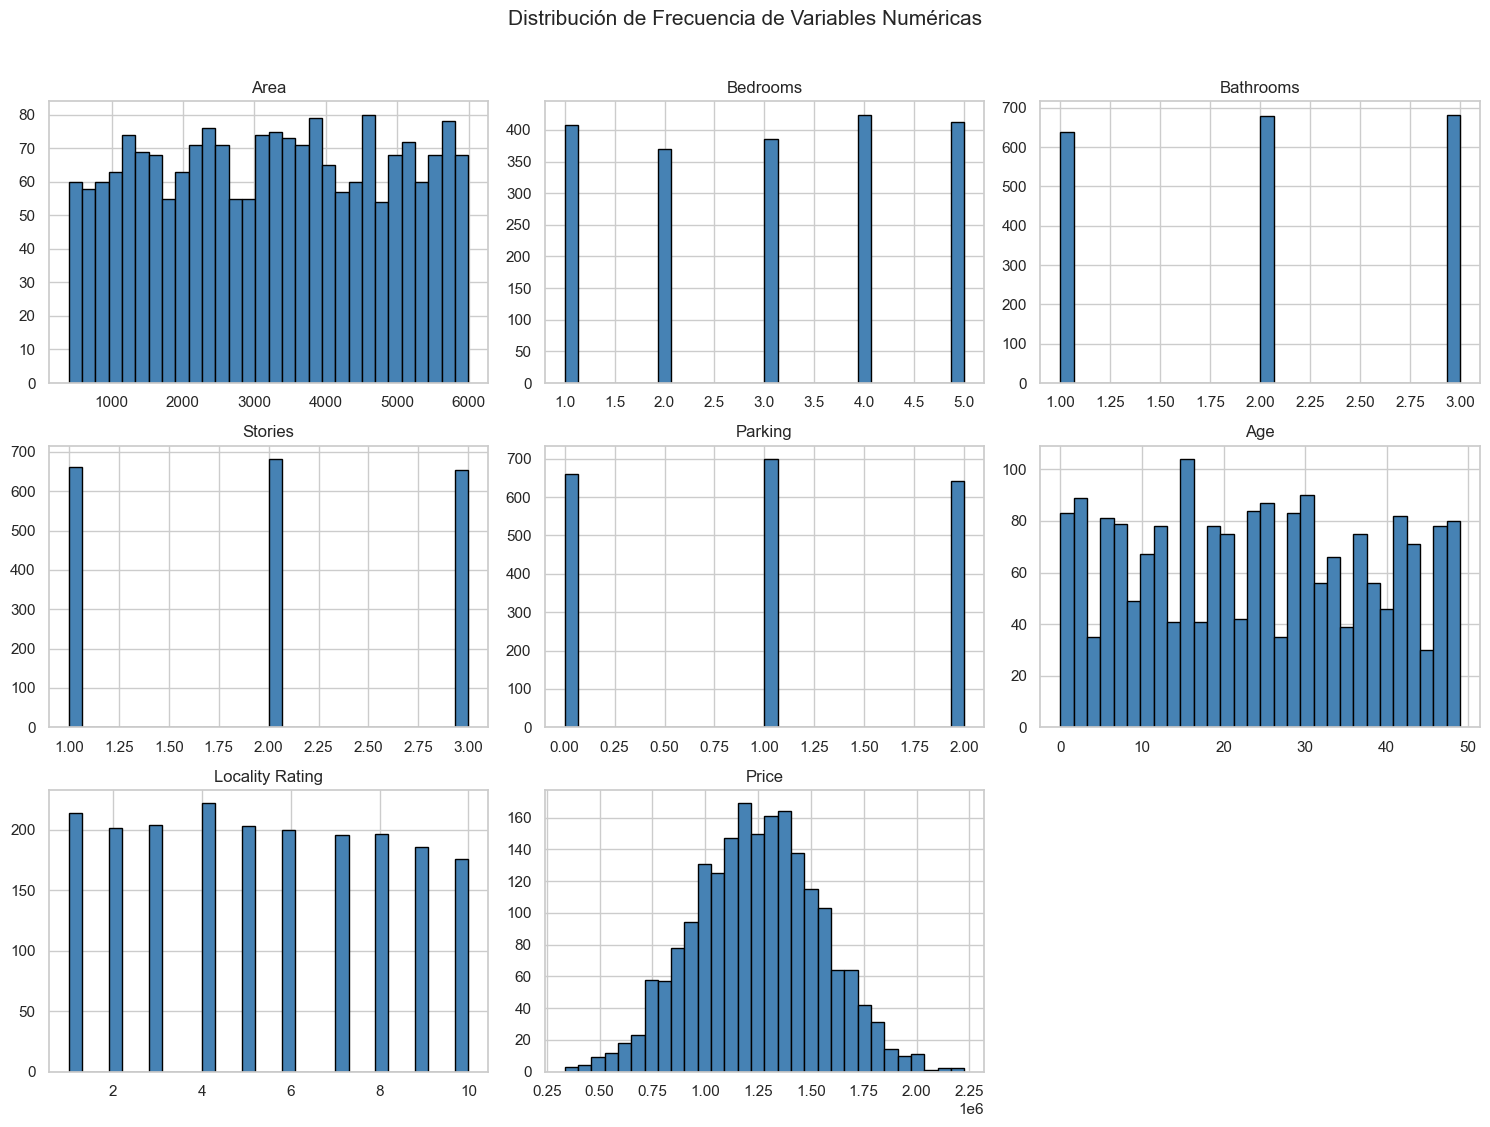

In [6]:
# Distribución univariada de todas las variables numéricas
num_cols_all = df.select_dtypes(include=["int64", "float64"]).columns

df[num_cols_all].hist(bins=30, figsize=(15, 11), color="steelblue", edgecolor="black")
plt.suptitle("Distribución de Frecuencia de Variables Numéricas", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


Los histogramas muestran que la variable objetivo `Price` sigue una distribución acampanada unimodal relativamente simétrica. Variables como `Area` y `Age` cubren rangos continuos de manera uniforme, mientras que `Bedrooms`, `Bathrooms`, `Stories`, `Parking` y `Locality Rating` presentan estructuras discretas sin acumulaciones anómalas.


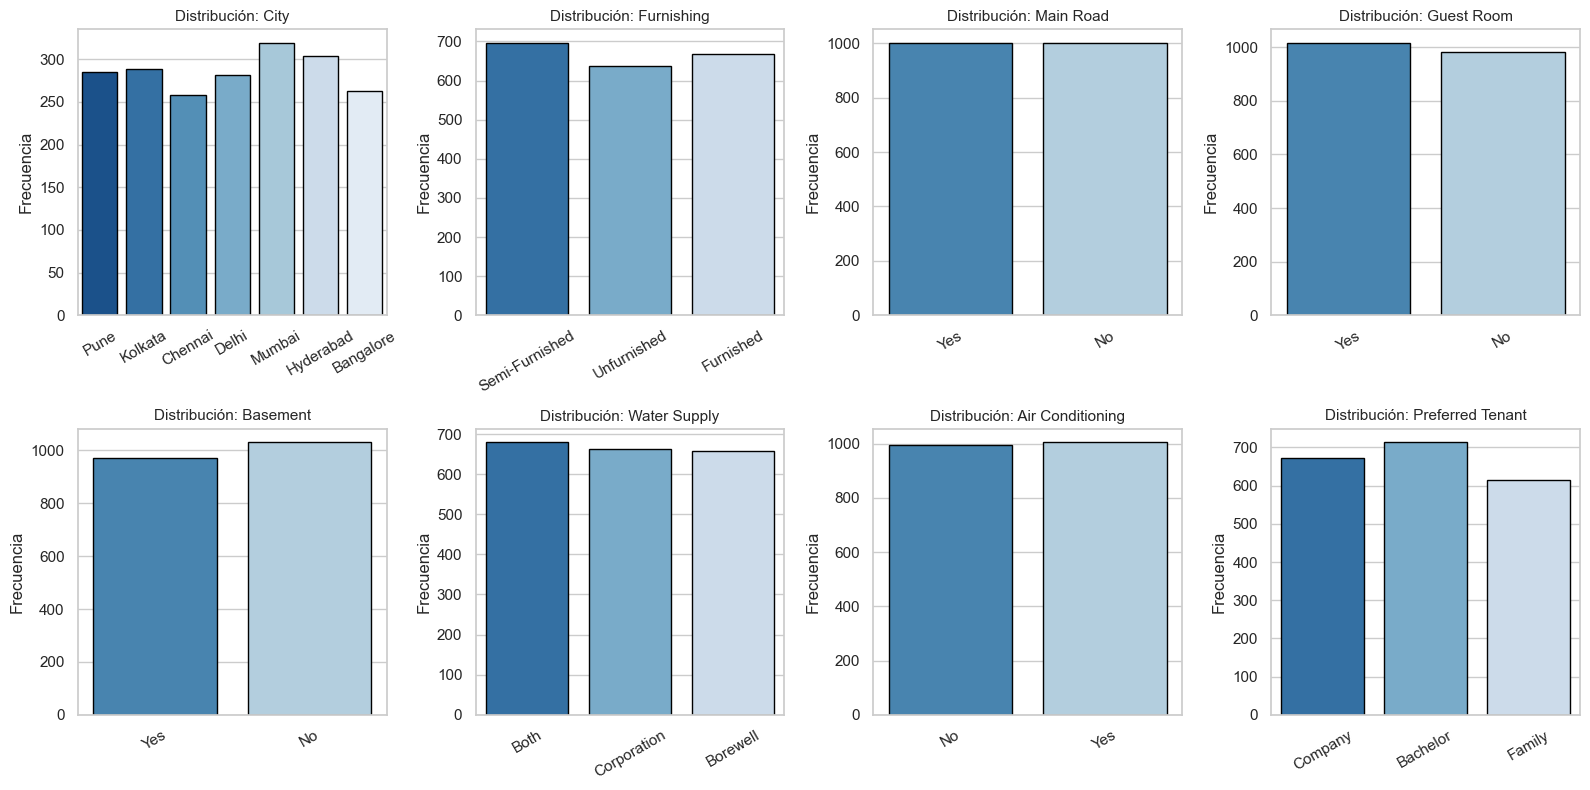

In [16]:
# Distribución de variables categóricas
cat_cols_all = df.select_dtypes(include=["object"]).columns

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols_all):
    sns.countplot(data=df, x=col, hue=col, ax=axes[i], palette="Blues_r", edgecolor="black", legend=False)
    axes[i].set_title(f"Distribución: {col}", fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frecuencia")
    axes[i].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

Las variables cualitativas exhiben proporciones representativas en cada categoría (ciudades, amueblado, servicios básicos, tipo de inquilino), lo que garantiza que la posterior codificación One-Hot genere columnas informativas sin problemas de categorías desbalanceadas extremas.


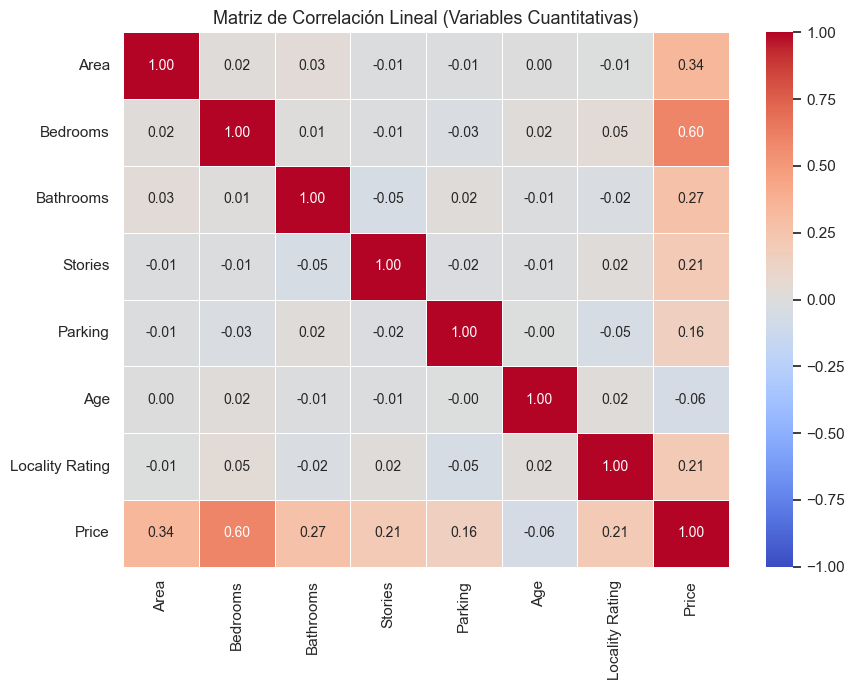

In [8]:
# Matriz de correlación lineal de Pearson entre variables numéricas
plt.figure(figsize=(9, 7))
num_df = df.select_dtypes(include=["number"])
corr_matrix = num_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Matriz de Correlación Lineal (Variables Cuantitativas)", fontsize=13)
plt.tight_layout()
plt.show()


La matriz de correlación confirma que `Price` mantiene relaciones directas positivas con variables como `Bathrooms`, `Area`, `Stories` y `Locality Rating`. Asimismo, la ausencia de correlaciones lineales elevadas entre las variables predictoras descarta problemas severos de multicolinealidad entre los predictores continuos.


### 4. Preparación y Partición del Conjunto de Datos

Se separa la variable objetivo continua (`Price`) del conjunto de características explicativas. La muestra se divide en tres particiones con semilla fija (`random_state=42`):
- **Entrenamiento (Train, 70 %)**: 1.400 observaciones para el ajuste inicial de los modelos y la ejecución de la validación cruzada.
- **Validación (Val, 15 %)**: 300 observaciones para evaluar la respuesta intermedia ante datos no vistos.
- **Prueba (Test, 15 %)**: 300 observaciones aisladas para la evaluación final no sesgada del modelo seleccionado.


In [9]:
X = df.drop(columns=["Price"])
y = df["Price"]

# Identificación explícita de tipos de columnas predictoras
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

# Partición en tres subconjuntos (70% Train, 15% Val, 15% Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Subconjunto de Entrenamiento (Train): {X_train.shape[0]} muestras ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Subconjunto de Validación (Val):       {X_val.shape[0]} muestras ({X_val.shape[0]/len(df)*100:.1f}%)")
print(f"Subconjunto de Prueba (Test):          {X_test.shape[0]} muestras ({X_test.shape[0]/len(df)*100:.1f}%)")


Subconjunto de Entrenamiento (Train): 1400 muestras (70.0%)
Subconjunto de Validación (Val):       300 muestras (15.0%)
Subconjunto de Prueba (Test):          300 muestras (15.0%)


### 5. Pipeline de Preprocesamiento

Para blindar el flujo frente a la fuga de información (data leakage), se construye un `ColumnTransformer` que estandariza las 7 variables numéricas mediante `StandardScaler` y transforma las 8 variables categóricas con `OneHotEncoder(drop='first')`. Este transformador se acopla internamente a cada algoritmo en un `Pipeline` de scikit-learn.


In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), cat_cols)
    ]
)


### 6. Definición de Modelos Supervisados

Se configuran seis algoritmos de regresión supervisada con sus parámetros por defecto:
1. **LinearRegression**: Regresión lineal clásica por mínimos cuadrados ordinarios.
2. **Ridge**: Regresión lineal con regularización $L_2$ para mitigar variabilidad.
3. **Lasso**: Regresión lineal con regularización $L_1$ para selección de variables.
4. **KNeighborsRegressor**: Regresión basada en proximidad geométrica de vecinos cercanos ($K=5$).
5. **DecisionTreeRegressor**: Modelo no paramétrico de partición recursiva del espacio.
6. **RandomForestRegressor**: Ensamble de múltiples árboles de decisión mediante promediación (bagging).


In [11]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(random_state=42),
    "KNeighborsRegressor": KNeighborsRegressor(),
    "DecisionTreeRegressor": DecisionTreeRegressor(random_state=42),
    "RandomForestRegressor": RandomForestRegressor(random_state=42)
}


### 7. Evaluación con Validación Cruzada (5-Fold CV)

Para cada algoritmo se cuantifica la raíz del error cuadrático medio (RMSE) en tres instancias:
1. **Train RMSE**: Error al evaluar el modelo sobre el mismo conjunto de entrenamiento.
2. **Val RMSE**: Error al predecir sobre el conjunto de validación intermedia.
3. **CV RMSE (Promedio y Desv. Est.)**: Estimación insesgada mediante validación cruzada K-Fold ($K=5$) aplicada exclusivamente sobre los datos de entrenamiento.


In [12]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = []
cv_scores_dict = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", model)
    ])
    
    # 1. Ajuste y evaluación en el conjunto de entrenamiento
    pipe.fit(X_train, y_train)
    y_train_pred = pipe.predict(X_train)
    train_rmse = root_mean_squared_error(y_train, y_train_pred)
    
    # 2. Evaluación en el conjunto de validación
    y_val_pred = pipe.predict(X_val)
    val_rmse = root_mean_squared_error(y_val, y_val_pred)
    
    # 3. Validación cruzada de 5 pliegues sobre entrenamiento
    cv_scores = -cross_val_score(pipe, X_train, y_train, cv=kf, scoring="neg_root_mean_squared_error")
    cv_scores_dict[name] = cv_scores
    
    results.append({
        "Modelo": name,
        "Train RMSE": train_rmse,
        "Val RMSE": val_rmse,
        "CV RMSE Promedio": cv_scores.mean(),
        "CV RMSE Desv. Est.": cv_scores.std()
    })

df_results = pd.DataFrame(results)
df_results


,Modelo,Train RMSE,Val RMSE,CV RMSE Promedio,CV RMSE Desv. Est.
0,LinearRegression,151664.632216,147163.691625,153650.866709,8544.541058
1,Ridge,151665.410854,147078.067424,153631.866624,8515.898337
2,Lasso,151664.632686,147161.017131,153649.705609,8544.413561
3,KNeighborsRegressor,168337.268048,195135.666021,207058.280505,8061.254931
4,DecisionTreeRegressor,0.000000,258748.759113,279887.981919,12878.552855
5,RandomForestRegressor,68962.290493,174660.153621,185373.071877,7170.950991


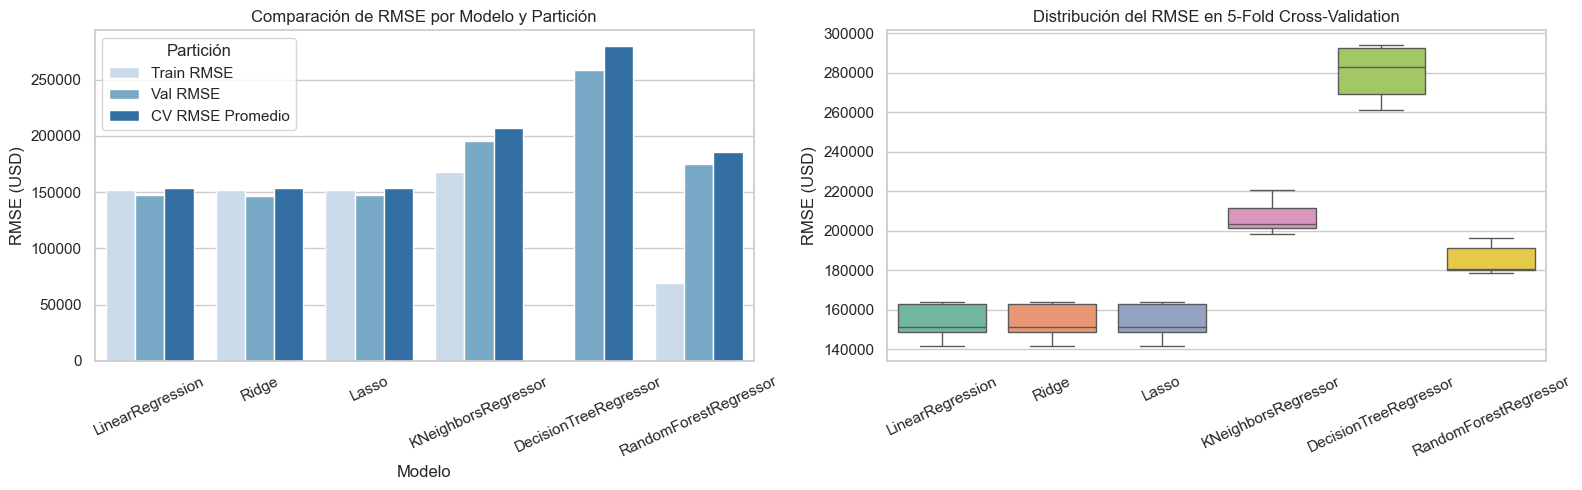

In [13]:
# Visualizaciones comparativas del rendimiento
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico de barras: Comparación de RMSE por Modelo y Partición
df_plot = df_results.melt(id_vars="Modelo", value_vars=["Train RMSE", "Val RMSE", "CV RMSE Promedio"], 
                          var_name="Partición", value_name="RMSE")
sns.barplot(data=df_plot, x="Modelo", y="RMSE", hue="Partición", ax=axes[0], palette="Blues")
axes[0].set_title("Comparación de RMSE por Modelo y Partición", fontsize=12)
axes[0].set_ylabel("RMSE (USD)")
axes[0].tick_params(axis="x", rotation=25)

# Boxplot: Dispersión del RMSE en los 5 pliegues de Validación Cruzada
df_cv_box = pd.DataFrame(cv_scores_dict)
sns.boxplot(data=df_cv_box, ax=axes[1], palette="Set2")
axes[1].set_title("Distribución del RMSE en 5-Fold Cross-Validation", fontsize=12)
axes[1].set_ylabel("RMSE (USD)")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


### 8. Discusión de Hallazgos y Selección del Modelo

El análisis comparativo de la tabla y los gráficos permite extraer las siguientes conclusiones:
- **Modelos Lineales (LinearRegression, Ridge y Lasso)**: Presentan el error más bajo y consistente en validación cruzada (~153.631 USD) y una desviación estándar acotada (~8.515 USD). La escasa diferencia entre el error de entrenamiento y el de validación confirma una excelente capacidad de generalización sin indicios de sobreajuste.
- **Árbol de Decisión**: Muestra un sobreajuste severo al memorizar por completo el entrenamiento (Train RMSE = 0 USD), lo que incrementa sustancialmente el error en validación cruzada (~279.887 USD), evidenciando alta varianza al no restringir la profundidad.
- **K-Vecinos más Cercanos (KNN)**: Registra un error intermedio (~207.058 USD en CV), afectado por el aumento dimensional tras la codificación de variables categóricas.
- **Random Forest**: Reduce la varianza del árbol individual gracias al ensamble, pero los modelos lineales continúan superándolo debido a la naturaleza esencialmente aditiva de los determinantes del precio residencial.

Dada su capacidad para regularizar coeficientes ante correlaciones moderadas y su bajo error, se selecciona **Ridge Regression** como el modelo definitivo.


### 9. Evaluación Final en el Conjunto de Prueba

El modelo seleccionado (Ridge) se entrena utilizando la totalidad del conjunto de entrenamiento (`X_train`) y se evalúa de manera concluyente sobre el conjunto de prueba aislado (`X_test`) mediante las métricas RMSE, MAE y $R^2$.


In [14]:
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge())
])

# Ajuste definitivo sobre el conjunto de entrenamiento
final_pipeline.fit(X_train, y_train)

# Predicción y cálculo de métricas en el conjunto de prueba
y_test_pred = final_pipeline.predict(X_test)

test_rmse = root_mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

cv_rmse_promedio = df_results.loc[df_results["Modelo"] == "Ridge", "CV RMSE Promedio"].values[0]

print("=== EVALUACIÓN DEFINITIVA EN EL CONJUNTO DE PRUEBA (RIDGE) ===")
print(f"RMSE en Validación Cruzada (Promedio): {cv_rmse_promedio:,.2f} USD")
print(f"RMSE en Conjunto de Prueba (Test):      {test_rmse:,.2f} USD")
print(f"Error Absoluto Medio - MAE (Test):     {test_mae:,.2f} USD")
print(f"Coeficiente de Determinación R² (Test): {test_r2:.4f}")


=== EVALUACIÓN DEFINITIVA EN EL CONJUNTO DE PRUEBA (RIDGE) ===
RMSE en Validación Cruzada (Promedio): 153,631.87 USD
RMSE en Conjunto de Prueba (Test):      145,802.31 USD
Error Absoluto Medio - MAE (Test):     117,322.33 USD
Coeficiente de Determinación R² (Test): 0.7466


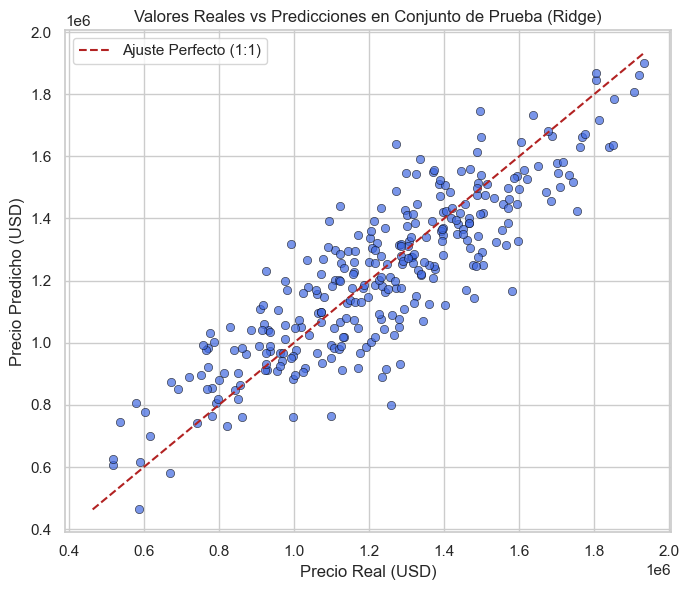

In [15]:
# Gráfico de dispersión: Valores Reales vs Predicciones en Prueba
plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.7, color="royalblue", edgecolor="black")
lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
plt.plot(lims, lims, color="firebrick", linestyle="--", linewidth=1.5, label="Ajuste Perfecto (1:1)")
plt.title("Valores Reales vs Predicciones en Conjunto de Prueba (Ridge)", fontsize=12)
plt.xlabel("Precio Real (USD)")
plt.ylabel("Precio Predicho (USD)")
plt.legend()
plt.tight_layout()
plt.show()


### 10. Conclusiones

1. **Validez de la Validación Cruzada**: El error obtenido en el conjunto de prueba independiente (145.802 USD) es coherente con la estimación obtenida en la validación cruzada K-Fold (153.631 USD +- 8.515 USD), lo que demuestra que el remuestreo proporciona una cota realista y robusta del rendimiento en producción.
2. **Bondad de Ajuste**: El coeficiente de determinación $R^2 = 0.7466$ refleja que el modelo lineal regularizado explica aproximadamente el 74.7 % de la variación del precio de las viviendas a partir de sus atributos arquitectónicos y geográficos.
3. **Control del Sobreajuste**: La comparación sistemática entre modelos paramétricos y no paramétricos ilustra cómo algoritmos de alta complejidad y flexibilidad (como árboles sin podar) pueden sobreajustar fácilmente, mientras que modelos lineales con penalización logran la mejor capacidad de generalización en datos tabulares estructurados.
